In [13]:
# do not change the code in the block below
# __________start of block__________
import json
import os
import re

import numpy as np
import torch
import torchvision
from IPython.display import clear_output
from matplotlib import pyplot as plt
from torch import nn
from torch.nn import functional as F
from torchvision.datasets import FashionMNIST
from torch.utils.data import DataLoader

# __________end of block__________

In [2]:
# do not change the code in the block below
# __________start of block__________
def get_predictions(model, eval_data, step=10):

    predicted_labels = []
    model.eval()
    with torch.no_grad():
        for idx in range(0, len(eval_data), step):
            y_predicted = model(eval_data[idx : idx + step].to(device))
            predicted_labels.append(y_predicted.argmax(dim=1).cpu())

    predicted_labels = torch.cat(predicted_labels)
    predicted_labels = ",".join([str(x.item()) for x in list(predicted_labels)])
    return predicted_labels


def get_accuracy(model, data_loader):
    predicted_labels = []
    real_labels = []
    model.eval()
    with torch.no_grad():
        for batch in data_loader:
            y_predicted = model(batch[0].to(device))
            predicted_labels.append(y_predicted.argmax(dim=1).cpu())
            real_labels.append(batch[1])

    predicted_labels = torch.cat(predicted_labels)
    real_labels = torch.cat(real_labels)
    accuracy_score = (predicted_labels == real_labels).type(torch.FloatTensor).mean()
    return accuracy_score


# __________end of block__________

In [9]:
import urllib.request
import numpy as np

url = "https://github.com/girafe-ai/ml-course/raw/24f_ysda/homeworks/hw_overfitting/hw_overfitting_data_dict"
urllib.request.urlretrieve(url, "hw_overfitting_data_dict.npy")

# Загрузка данных
data = np.load("hw_overfitting_data_dict.npy", allow_pickle=True).item()

In [10]:
# do not change the code in the block below
# __________start of block__________
assert os.path.exists(
    "hw_overfitting_data_dict.npy"
), "Please, download `hw_overfitting_data_dict.npy` and place it in the working directory"

# __________end of block__________

In [11]:
CUDA_DEVICE_ID = 0
# do not change the code in the block below
# __________start of block__________
device = (
    torch.device(f"cuda:{CUDA_DEVICE_ID}") if torch.cuda.is_available() else torch.device("cpu")
)
# __________end of block__________

Text(0.5, 1.0, 'Image label: 2')

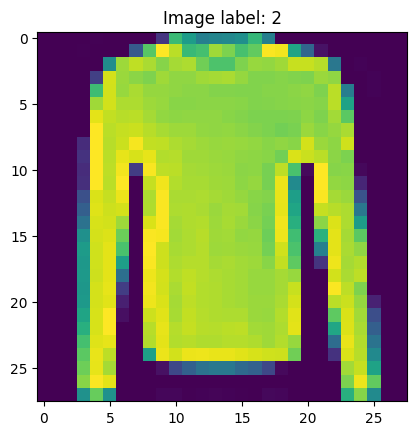

In [14]:
train_fmnist_data = FashionMNIST(".", train = True, download = True, transform = torchvision.transforms.ToTensor())
test_fmnist_data = FashionMNIST(".", train = False, download = True, transform = torchvision.transforms.ToTensor())

train_data_loader = DataLoader(train_fmnist_data, batch_size = 32, shuffle = True, num_workers = 2)
test_data_loader = DataLoader(test_fmnist_data, batch_size = 32, shuffle = False, num_workers = 2)

random_batch = next(iter(train_data_loader))
_image, _label = random_batch[0][0], random_batch[1][0]
plt.figure()
plt.imshow(_image.reshape(28, 28))
plt.title(f"Image label: {_label}")


In [18]:
class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_model = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.GELU(),
            nn.Linear(512, 256),
            nn.GELU(),
            nn.Linear(256, 128),
            nn.GELU(),
            nn.Linear(128, 10)
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_model(x)
        return logits
    
model = NeuralNetwork().to(device)
print(model)

NeuralNetwork(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (linear_model): Sequential(
    (0): Linear(in_features=784, out_features=512, bias=True)
    (1): GELU(approximate='none')
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): GELU(approximate='none')
    (4): Linear(in_features=256, out_features=128, bias=True)
    (5): GELU(approximate='none')
    (6): Linear(in_features=128, out_features=10, bias=True)
  )
)


In [23]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr = 0.005)

def train(train_data_loader, model, loss_fn, optimizer):
    model.train()
    for batch, (X, y) in enumerate(train_data_loader):
        X, y = X.to(device), y.to(device)
        pred = model(X)
        loss = loss_fn(pred, y)

        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 ==0:
            loss, current = loss.item(), (batch + 1) * len(X)
            print(f"Loss = {loss:.5f}, current = {current:.4f}")


def test(test_data_loader, model, loss_fn):
    num_batches = len(test_data_loader)
    size = len(test_data_loader.dataset)
    model.eval()
    test_loss, correct = 0, 0
    with torch.no_grad():
        for X, y in test_data_loader:
            X, y = X.to(device), y.to(device)
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()
    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

In [25]:
epochs = 5
for i in range(epochs):
    print(f"Epochs {i + 1}-------------------")
    train(train_data_loader, model, loss_fn, optimizer)
    test(test_data_loader, model, loss_fn)
print("Done!")

Epochs 1-------------------
Loss = 0.46899, current = 32.0000
Loss = 0.32123, current = 3232.0000
Loss = 0.47320, current = 6432.0000
Loss = 0.44038, current = 9632.0000
Loss = 0.46367, current = 12832.0000
Loss = 0.48085, current = 16032.0000
Loss = 0.72045, current = 19232.0000
Loss = 0.56292, current = 22432.0000
Loss = 0.66818, current = 25632.0000
Loss = 0.36826, current = 28832.0000
Loss = 0.36385, current = 32032.0000
Loss = 0.82476, current = 35232.0000
Loss = 0.31852, current = 38432.0000
Loss = 0.61412, current = 41632.0000
Loss = 0.38054, current = 44832.0000
Loss = 0.61515, current = 48032.0000
Loss = 0.33482, current = 51232.0000
Loss = 0.21240, current = 54432.0000
Loss = 0.54365, current = 57632.0000
Test Error: 
 Accuracy: 82.0%, Avg loss: 0.498073 

Epochs 2-------------------
Loss = 0.38593, current = 32.0000
Loss = 0.59223, current = 3232.0000
Loss = 0.30279, current = 6432.0000
Loss = 0.34813, current = 9632.0000
Loss = 0.55175, current = 12832.0000
Loss = 0.41986, 